In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# plt.rcParams['font.family'] = 'Malgun Gothic' # For Windows
plt.rcParams["font.family"] = "AppleGothic"   # Mac
%matplotlib inline

In [2]:
df=pd.read_csv("../공유/final_cleaned_airbnb.csv")

In [10]:
# 점유율 = 숙박일수 / 365
df['occupancy_rate'] = df['estimated_occupancy_l365d'] / 365

In [11]:
# 연매출 = 1박 가격 * 숙박일수
df['calc_revenue'] = df['price'] * df['estimated_occupancy_l365d']

연매출 , 점유율이 58%가 0인 값이 많아서 이런 결과 값이 나옴.
근데 퀸즈와 아일랜드에는 값이 찍힘.
여기서. 만약 운영되지 않은 숙소가 많아서 0이 찍히는 거라면???

목표는 가격전략을 할수도 있고, 또 페르소나 (호스트들에게 투자금에 따라 블루오션에서 어디 레드오션에서 어디를 추천) => 을 할거라면 실제 운영중인 +실제 매출 을 봐야하지 않을까?
 그렇다면 운영중이지 않은(실제매출을 설명할수 없음과 0의 비율이 50%이상으로 문자열 상관분석에 영향을 준다면??))
 1. 운영중이지 않은 숙소가 brox,brooklyn, manhattan이 가장 많은 때, 우리는 지금 값이 찍히는 Q지역과 iland 지역을 추천 할 수 있을까? 실제 매출과 비교를 했나? 즉. 실제 운영중인 숙소들에 대한 실제 매출 데이터냐???
 -> 확인해보기
 
 비운영 -> 추정 연매출이 0이다.
 향후 365예약이 0이다. -> 비활성 또는 오랫동안 일 안함

In [12]:
df.groupby('neighbourhood_group_cleansed').agg(
    total_listing=('price', 'count'),
    zero_revenue=('estimated_revenue_l365d', lambda x: (x==0).sum()),
    zero_availability=('availability_365', lambda x: (x==0).sum())
).reset_index()

,neighbourhood_group_cleansed,total_listing,zero_revenue,zero_availability
0,Bronx,814,481,12
1,Brooklyn,6585,3729,23
2,Manhattan,9125,5629,101
3,Queens,3054,1686,17
4,Staten Island,283,139,1


In [13]:
#  운영 안하는 숙소 확인하기 => 위의 zero_revenue의 합산과 아래의 합산 값이 같음.
df[(df['estimated_revenue_l365d']==0) | (
df['availability_365']==0)
].shape

(11707, 61)

In [14]:
len(df[df['estimated_revenue_l365d']==0])

11664

In [15]:
len(df[df['availability_365']==0])

154

In [16]:
#  운영 안하는 숙소 확인하기 => 위의 zero_revenue의 합산과 아래의 합산 값이 같음.
df[(df['estimated_revenue_l365d']==0) | (
df['availability_365']==0)
].shape

(11707, 61)

전체 데이터 중 약 58%가 매출 0으로 나타났으며 이는 실제 운영되지 않는 숙소 또는 예약이 발생하지 않은 숙소일 가능성이 있다. 이러한 데이터는 매출 예측 모델의 왜곡을 초래할 수 있으므로 매출이 발생한 숙소만을 대상으로 회귀 분석을 진행하였다.
따라 수치형 변수와의 상관관계 분석과 문자열 변수와의 상관관계 분석을 운영되지 않는 숙소를 제거한 동일한 데이터로 분석을 한다.
매출예측 모델 왜곡 방지를 위해 제거 >>>
분석 기준이 서로 다른것을 방지하기 위한>> 해석의 일관성

In [17]:
df_active = df[df['estimated_revenue_l365d'] > 0]
df_active['estimated_revenue_l365d'].describe()
np.log1p(df_active['estimated_revenue_l365d'])

3         9.904537
5         9.757363
7         9.746015
13       10.146473
14       10.427654
           ...    
18990     7.478170
19033     9.387733
19042     8.221748
19141     7.965893
19163     8.037543
Name: estimated_revenue_l365d, Length: 8197, dtype: float64

In [18]:
# 운영 숙소만 필터
df_active = df[df['estimated_revenue_l365d'] > 0].copy()

# 3️⃣ df_active에 원본 연매출 컬럼 넣기
# 행 순서가 df_active가 df에서 그대로 떨어졌다면 이렇게 바로 가져와도 됨
df_active['calc_revenue'] = df.loc[df_active.index, 'calc_revenue']

In [19]:
df_active_summary=df_active.groupby(['neighbourhood_group_cleansed','property_regulation_type','room_type']).agg(
    listing_count=('price','count'),
    occupancy_meian=('occupancy_rate','median'),
    price_median=('price','median'),
    revenue_median=('calc_revenue','median')
).reset_index()
df_active_summary

,neighbourhood_group_cleansed,property_regulation_type,room_type,listing_count,occupancy_meian,price_median,revenue_median
0,Bronx,Residential_long_term,Entire home/apt,113,0.328767,97.0,10200.0
1,Bronx,Residential_long_term,Private room,142,0.328767,50.0,5250.0
2,Bronx,Residential_short_term,Private room,78,0.698630,89.0,21015.0
3,Brooklyn,Hotel,Hotel room,3,0.139726,184.0,9384.0
4,Brooklyn,Hotel,Private room,28,0.421918,175.5,22977.0
5,Brooklyn,Residential_long_term,Entire home/apt,1380,0.328767,148.0,20280.0
6,Brooklyn,Residential_long_term,Private room,795,0.328767,60.0,6820.0
7,Brooklyn,Residential_short_term,Private room,650,0.698630,121.0,25500.0
8,Manhattan,Hotel,Hotel room,69,0.071233,391.0,10504.0
9,Manhattan,Hotel,Private room,368,0.350685,201.0,27772.5


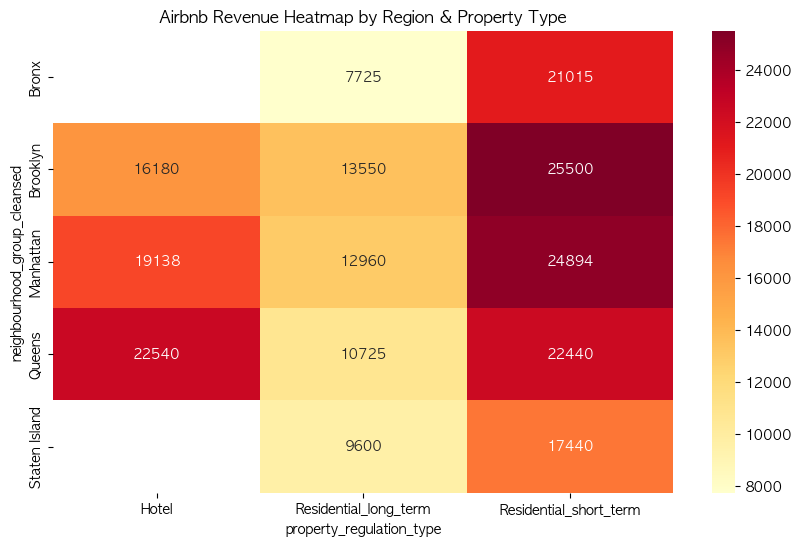

In [20]:
# 어떤지역 어떤 숙소타입이 수익이 높고 경쟁이 심할지. ---> brooklyn 지역의 단기임대가 점유율 이 높다.
import seaborn as sns
import matplotlib.pyplot as plt

# pivot 테이블 만들기
pivot = df_active_summary.pivot_table(
    index='neighbourhood_group_cleansed', 
    columns='property_regulation_type', 
    values='revenue_median'
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd") # 밝을수록 수익 높음
plt.title('Airbnb Revenue Heatmap by Region & Property Type')
plt.show()

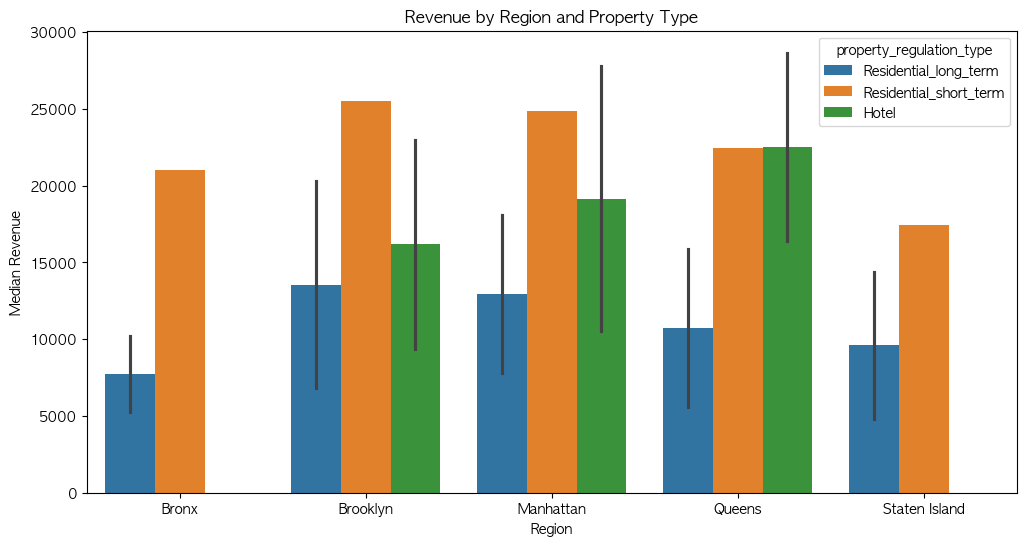

In [21]:
# 경쟁 강도 대비 수익 비교
plt.figure(figsize=(12,6))
sns.barplot(
    data=df_active_summary, 
    x='neighbourhood_group_cleansed', 
    y='revenue_median', 
    hue='property_regulation_type'
)
plt.title('Revenue by Region and Property Type')
plt.ylabel('Median Revenue')
plt.xlabel('Region')
plt.show()